#Universidad de Buenos Aires - FIUBA - LSE
#Visión por computadora - TP3
#Cohorte 25 - 3er bimestre 2026

**Integrantes:**

a2413, César Hernán Ruggeri

a2512, Armando Tomás Civini

a2521, Andrea Tatiana Duran

a2525, Pablo David Gorosito

a2542, Federico Tombesi

In [37]:
from pathlib import Path
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Ruta a la carpeta de imágenes locales
IMAGES_DIR = Path("images")

# Listar todas las imágenes disponibles
if IMAGES_DIR.exists():
    image_files = sorted(IMAGES_DIR.glob("*.*"))
    image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    
    print(f"Imágenes encontradas ({len(image_files)}):")
    for img_file in image_files:
        print(f"  - {img_file.name}")
else:
    print(f"La carpeta {IMAGES_DIR} no existe")

Imágenes encontradas (7):
  - COCA-COLA-LOGO.jpg
  - coca_logo_1.png
  - coca_logo_2.png
  - coca_multi.png
  - coca_retro_1.png
  - coca_retro_2.png
  - logo_1.png


In [38]:
print("Current directory:", Path.cwd())

# Mostrar contenido de la carpeta de imágenes locales
print("\nContenido de la carpeta 'images':")
for img_file in sorted(IMAGES_DIR.iterdir()):
    print(f"  {img_file.name}")

Current directory: /Users/pablogorosito/Documents/ESPECIALIZACION INTELIGENCIA ARTIFICIAL/TP_03_Vision_por_computadora

Contenido de la carpeta 'images':
  COCA-COLA-LOGO.jpg
  coca_logo_1.png
  coca_logo_2.png
  coca_multi.png
  coca_retro_1.png
  coca_retro_2.png
  logo_1.png


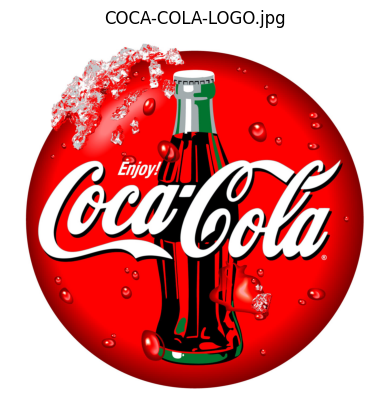

In [39]:
# Cargar las imágenes desde las carpetas locales
img = cv.imread(str(IMAGES_DIR / "COCA-COLA-LOGO.jpg"))
template = cv.imread(str(Path("template") / "pattern.png"), cv.IMREAD_GRAYSCALE)

# Mostrar la imagen
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.title("COCA-COLA-LOGO.jpg")
plt.show()

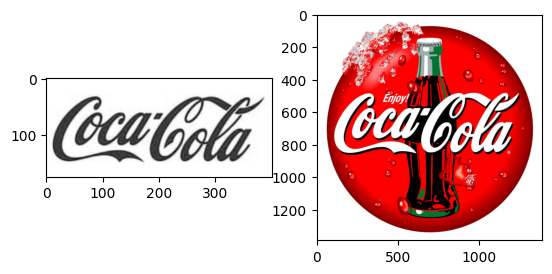

In [40]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure()
plt.subplot(1,2,1)
plt.imshow(template, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_rgb)

In [41]:
print(template.shape)
print(img_gray.shape)

(175, 400)
(1389, 1389)


In [42]:
def template_match(img_rgb, img_gray, template, meth):
    # Hago una copia de la imagen porque ciclo a ciclo le dibujo rectángulos
    img_salida = img_rgb.copy()
    w, h = template.shape[::-1]

    method = eval(meth)

    # Aplicamos la coincidencia de patrones
    #--------------------------------------
    res = cv.matchTemplate(img_gray, template, method)

    # Encontramos los valores máximos y mínimos
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    # Si el método es TM_SQDIFF o TM_SQDIFF_NORMED, tomamos el mínimo
    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    # Marcamos el lugar donde lo haya encontrado
    #----------------------------------------
    top_left = (top_left[0], top_left[1])
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv.rectangle(img_salida, top_left, bottom_right, 255, 10)

    # Graficamos el procesamiento y la salida
    #----------------------------------------
    plt.figure()

    # Resultado de coincidencia
    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])

    # Imagen original con recuadros
    plt.subplot(122), plt.imshow(img_salida)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])

    plt.suptitle(meth)
    plt.show()

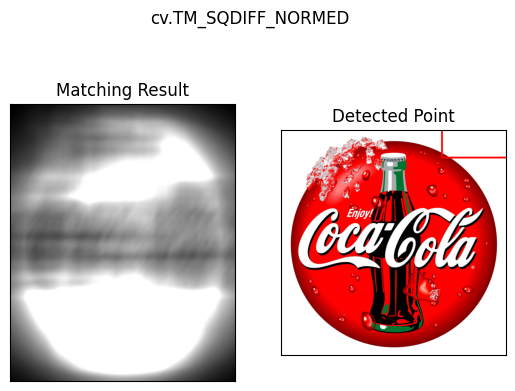

In [43]:
#Prueba sin filtros
template_match(img_rgb, img_gray, template, 'cv.TM_SQDIFF_NORMED')

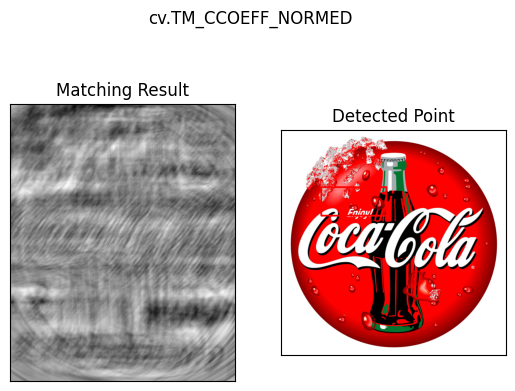

In [44]:
# Aplicamos el detector de bordes de Canny
img_canny = cv.Canny(img_gray, 100, 200)

template_match(img_rgb, img_canny, template, 'cv.TM_CCOEFF_NORMED')

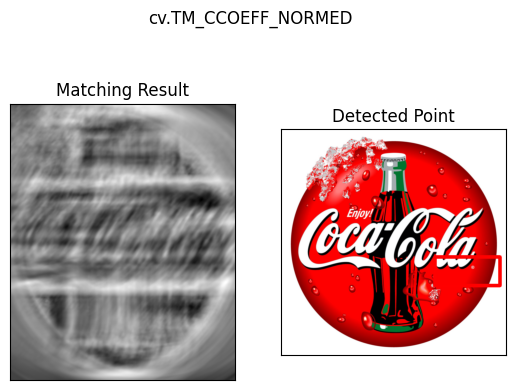

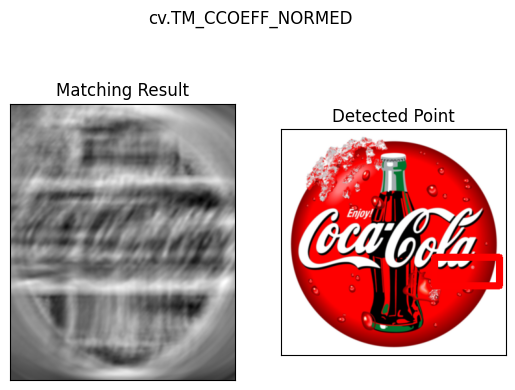

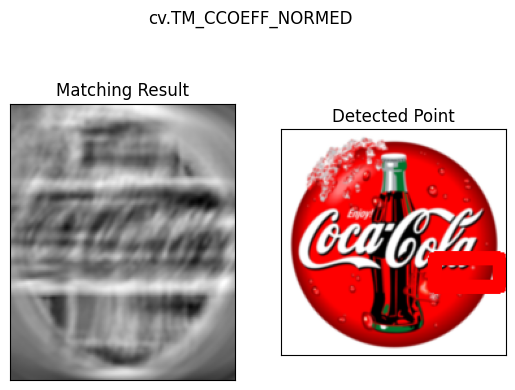

In [45]:
img_pyr_1 = cv.pyrDown(img_gray)
template_pyr_1 = cv.pyrDown(template)
img_rgb_pyr_1 = cv.pyrDown(img_rgb)

img_pyr_2 = cv.pyrDown(img_pyr_1)
template_pyr_2 = cv.pyrDown(template_pyr_1)
img_rgb_pyr_2 = cv.pyrDown(img_rgb_pyr_1)

img_pyr_3 = cv.pyrDown(img_pyr_2)
template_pyr_3 = cv.pyrDown(template_pyr_2)
img_rgb_pyr_3 = cv.pyrDown(img_rgb_pyr_2)

template_match(img_rgb_pyr_1, img_pyr_1, template_pyr_1, 'cv.TM_CCOEFF_NORMED')
template_match(img_rgb_pyr_2, img_pyr_2, template_pyr_2, 'cv.TM_CCOEFF_NORMED')
template_match(img_rgb_pyr_3, img_pyr_3, template_pyr_3, 'cv.TM_CCOEFF_NORMED')

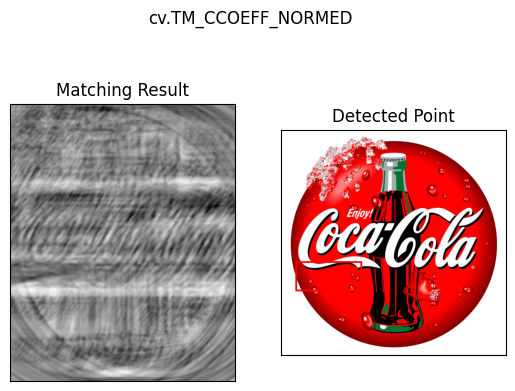

In [46]:
# Aplicar dos desenfoques gaussianos
g1 = cv.GaussianBlur(img_gray, (0, 0), sigmaX=3)
g2 = cv.GaussianBlur(img_gray, (0, 0), sigmaX=6)

# Difference of Gaussians
dog = cv.subtract(g1, g2)

template_match(img_rgb, dog, template, 'cv.TM_CCOEFF_NORMED')

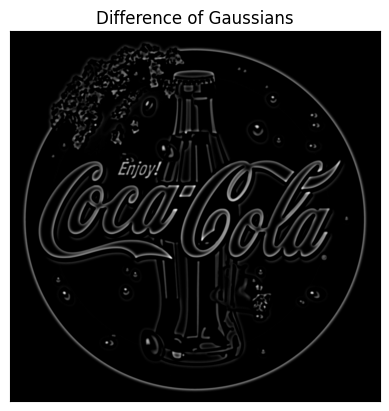

In [47]:
plt.figure()
plt.imshow(dog, cmap='gray')
plt.title('Difference of Gaussians')
plt.xticks([]), plt.yticks([])
plt.show()

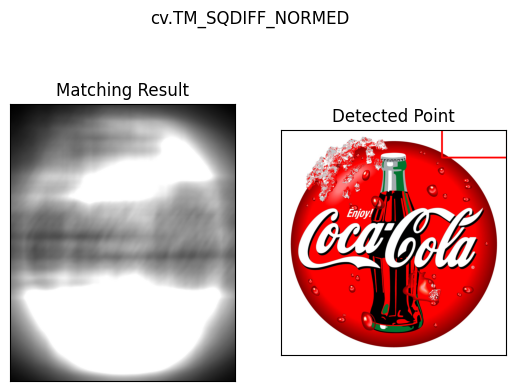

In [48]:
# Aplicamos un desenfoque Gaussiano
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=2)

# Unsharp Masking
unsharp = cv.addWeighted(img_gray, 1.5, blur, -0.5, 0)

template_match(img_rgb, unsharp, template, 'cv.TM_SQDIFF_NORMED')

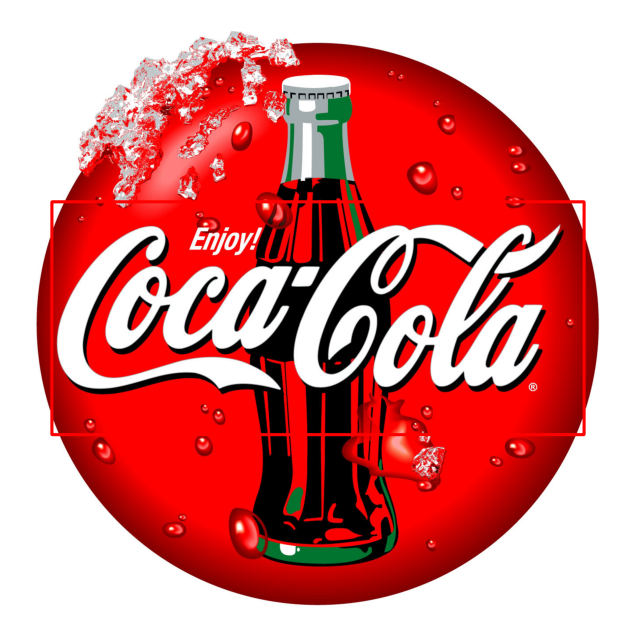

In [49]:
# Cambiá estos valores hasta que el rectángulo coincida con el logo
#p para chequear 1/3 es mas o menos la escala del logo a la foto
w = 400 * 3
h = 175 * 3

img_box = img_rgb.copy()

img_h, img_w = img_box.shape[:2]

top_left = ((img_w - w) // 2, (img_h - h) // 2)
bottom_right = (top_left[0] + w, top_left[1] + h)

cv.rectangle(img_box, top_left, bottom_right, (255, 0, 0), 5)

plt.figure(figsize=(8, 8))
plt.imshow(img_box)
plt.axis("off")
plt.show()

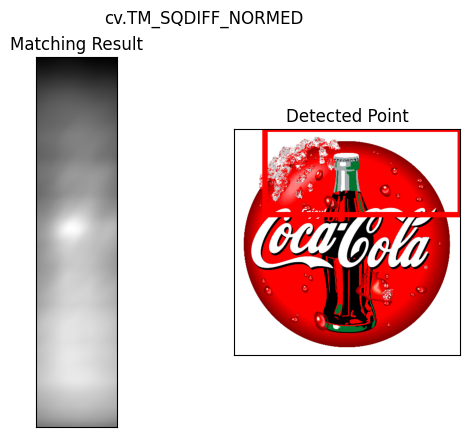

In [50]:
# solo con escala correcta tampoco matchea
img_scaled = cv.resize(img_gray, None, fx=1/3, fy=1/3)
img_rgb_scaled = cv.resize(img_rgb, None, fx=1/3, fy=1/3)

template_match(img_rgb_scaled, img_scaled, template, 'cv.TM_SQDIFF_NORMED')

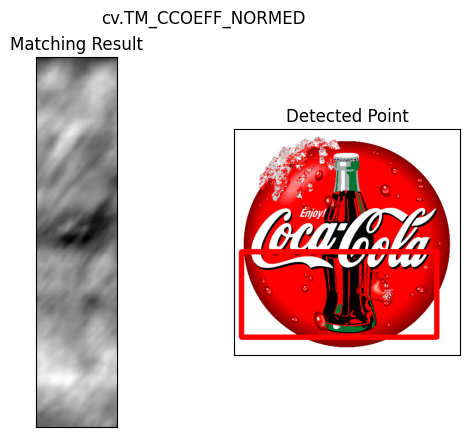

In [51]:
# ahora canny y escala
img_canny = cv.Canny(img_scaled, 100, 200)

template_match(img_rgb_scaled, img_canny, template, 'cv.TM_CCOEFF_NORMED')

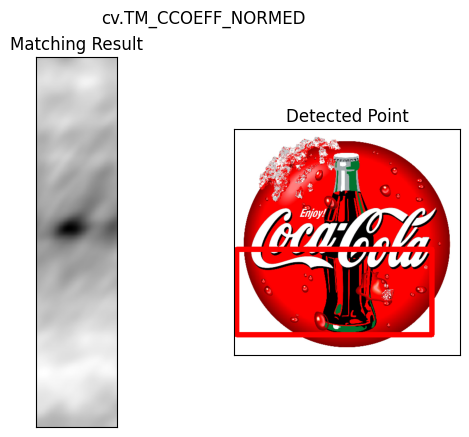

In [52]:
# escala mas dog
g1 = cv.GaussianBlur(img_scaled, (0, 0), sigmaX=3)
g2 = cv.GaussianBlur(img_scaled, (0, 0), sigmaX=6)

dog = cv.subtract(g1, g2)

template_match(img_rgb_scaled, dog, template, 'cv.TM_CCOEFF_NORMED')

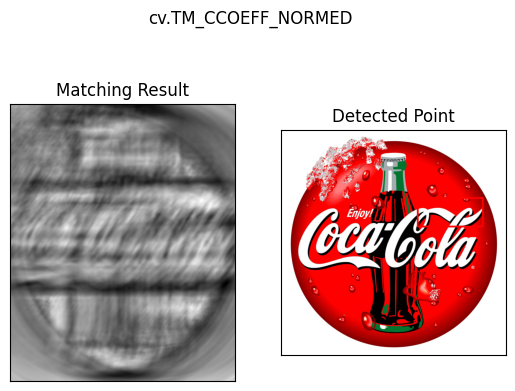

In [53]:
#con template invertido
template_inv = cv.subtract(255, template)


template_match(img_rgb, img_gray, template_inv, 'cv.TM_CCOEFF_NORMED')

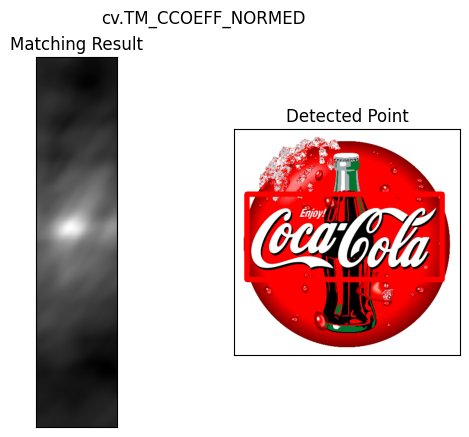

In [54]:
#con template invertido y escala
template_inv = cv.subtract(255, template)


template_match(img_rgb_scaled, img_scaled, template_inv, 'cv.TM_CCOEFF_NORMED')

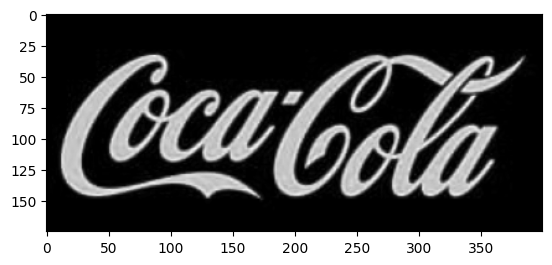

In [55]:
plt.imshow(template_inv, cmap='gray')

### Punto 2. Plantear y validar un algoritmo para multiples detecciones en la imagen coca_multi.png con el mismo template del ítem 1.

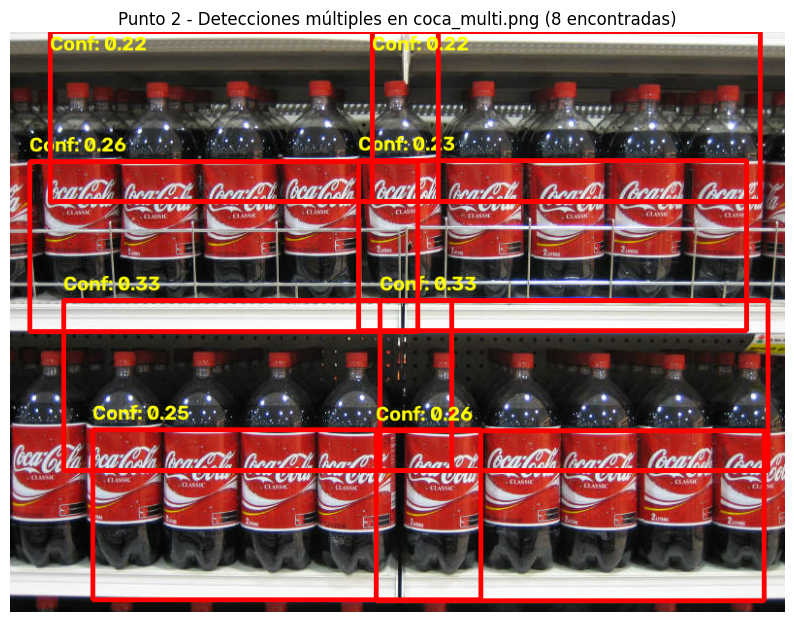

In [56]:
def mostrar_imagen(img, titulo=""):
    """
    Muestra una imagen utilizando Matplotlib en una ventana de tamaño adecuado.
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

# Supresión de no máximos
def non_max_suppression(boxes, overlapThresh=0.3):
    """
    Filtra cuadros delimitadores (bounding boxes) superpuestos basándose
    en sus puntuaciones de confianza (scores) para evitar detecciones duplicadas.
    """
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    # Extraemos coordenadas y puntajes de confianza
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]

    # Calculamos el área de cada cuadro delimitador
    area = (x2 - x1 + 1) * (y2 - y1 + 1)

    # Ordenamos los índices por puntuación de menor a mayor
    idxs = np.argsort(scores)

    while len(idxs) > 0:
        # Tomar el último índice (el de mayor puntuación)
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        # Encontrar las coordenadas del área de solapamiento
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        # Calcular ancho y alto de la intersección
        w_overlap = np.maximum(0, xx2 - xx1 + 1)
        h_overlap = np.maximum(0, yy2 - yy1 + 1)

        # Calcular el porcentaje de solapamiento
        overlap = (w_overlap * h_overlap) / area[idxs[:last]]

        # Eliminar los índices que superen el umbral de solapamiento
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))

    return boxes[pick]

# Ejecución
if __name__ == "__main__":

    # Usar rutas relativas locales
    template_path = Path("template") / "pattern.png"
    path_multi = Path("images") / "coca_multi.png"

    # Verificar que existan ambos archivos antes de procesar
    if not template_path.exists():
        print(f"ERROR: No se encontró la plantilla en: {template_path}")
        print(f"Directorio actual: {Path.cwd()}")
        print(f"Archivos en 'template/': {list(Path('template').glob('*')) if Path('template').exists() else 'carpeta no existe'}")
    elif not path_multi.exists():
        print(f"ERROR: No se encontró la imagen de prueba en: {path_multi}")
        print(f"Directorio actual: {Path.cwd()}")
        print(f"Archivos en 'images/': {list(Path('images').glob('*')) if Path('images').exists() else 'carpeta no existe'}")
    else:
        # Cargar plantilla e imagen objetivo
        template = cv.imread(str(template_path), cv.IMREAD_GRAYSCALE)
        img_multi_bgr = cv.imread(str(path_multi))

        if template is not None and img_multi_bgr is not None:
            # Obtener las dimensiones de la plantilla
            h, w = template.shape[:2]

            # Convertir la imagen objetivo a escala de grises
            img_multi_gray = cv.cvtColor(img_multi_bgr, cv.COLOR_BGR2GRAY)

            # Aplicar coincidencia de plantillas (Template Matching)
            res = cv.matchTemplate(img_multi_gray, template, cv.TM_CCOEFF_NORMED)

            # Definir umbral de detección
            threshold_multi = 0.15
            loc = np.where(res >= threshold_multi)

            # Recopilar las detecciones iniciales (brutas)
            raw_boxes = []
            for pt in zip(*loc[::-1]):
                score = res[pt[1], pt[0]]
                raw_boxes.append([pt[0], pt[1], pt[0] + w, pt[1] + h, score])

            # Aplicar Supresión de No Máximos para eliminar duplicados
            final_boxes = non_max_suppression(raw_boxes, overlapThresh=0.3)

            # Preparar la imagen para dibujar los resultados (convertir de BGR a RGB)
            img_multi_draw = cv.cvtColor(img_multi_bgr, cv.COLOR_BGR2RGB)

            # Dibujar los cuadros delimitadores y el texto de confianza
            for box in final_boxes:
                x1, y1, x2, y2, score = int(box[0]), int(box[1]), int(box[2]), int(box[3]), box[4]

                # Rectángulo rojo brillante para destacar la detección
                cv.rectangle(img_multi_draw, (x1, y1), (x2, y2), (255, 0, 0), 3)

                # Etiqueta en amarillo para alta visibilidad
                texto = f"Conf: {score:.2f}"
                cv.putText(
                    img_multi_draw,
                    texto,
                    (x1, max(y1 - 10, 20)),
                    cv.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 255, 0),
                    2
                )

            # Visualizar el resultado final
            mostrar_imagen(
                img_multi_draw,
                f"Punto 2 - Detecciones múltiples en coca_multi.png ({len(final_boxes)} encontradas)"
            )
        else:
            print("ERROR: Ocurrió un problema al leer las imágenes mediante OpenCV.")
            if template is None:
                print(f"  - El template no se cargó correctamente desde: {template_path}")
            if img_multi_bgr is None:
                print(f"  - La imagen no se cargó correctamente desde: {path_multi}")

### Punto 3 - Algoritmo Generalizado con Multiescala para todas las imagenes

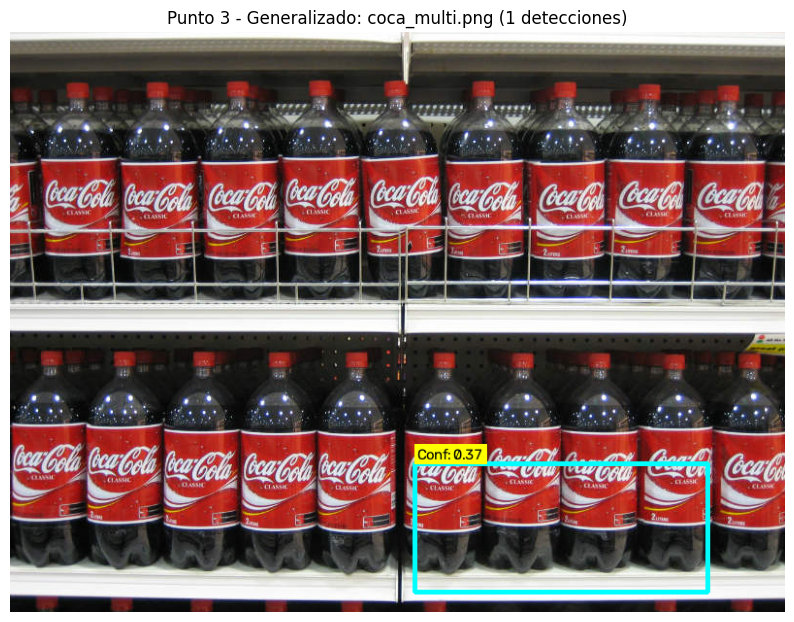

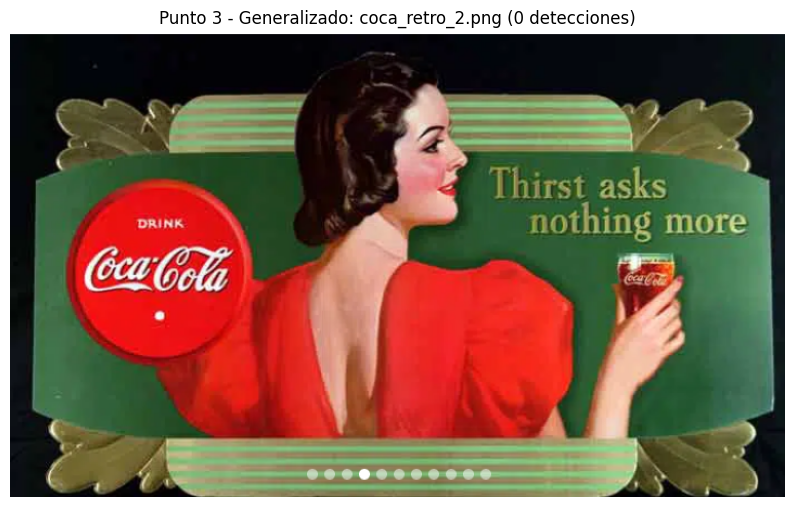

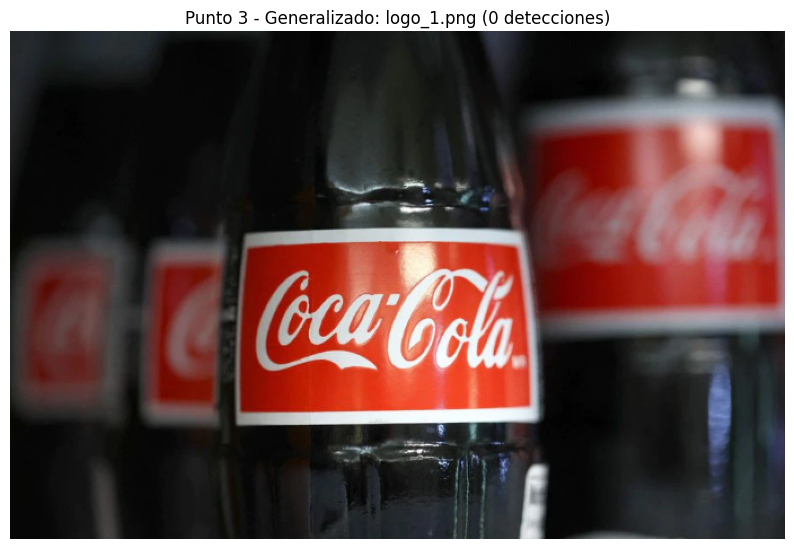

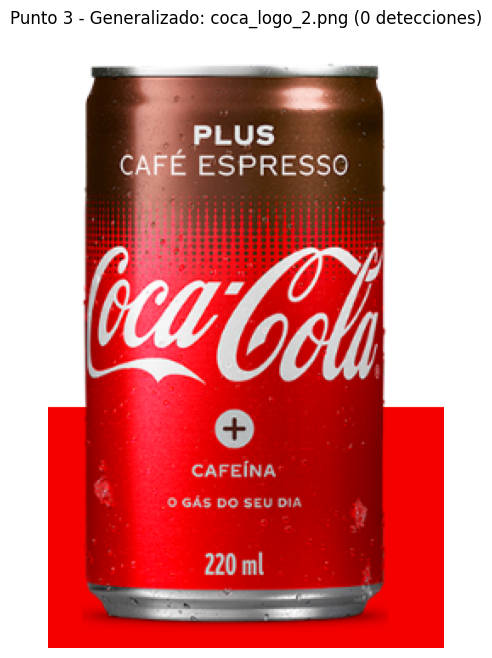

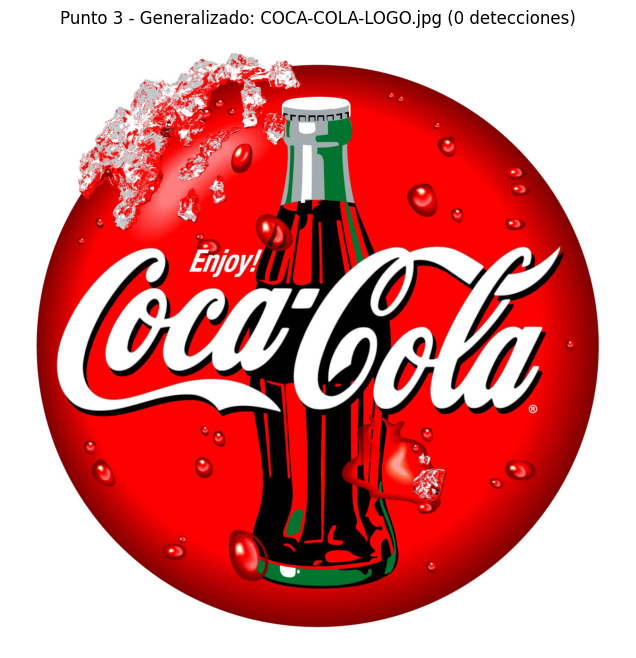

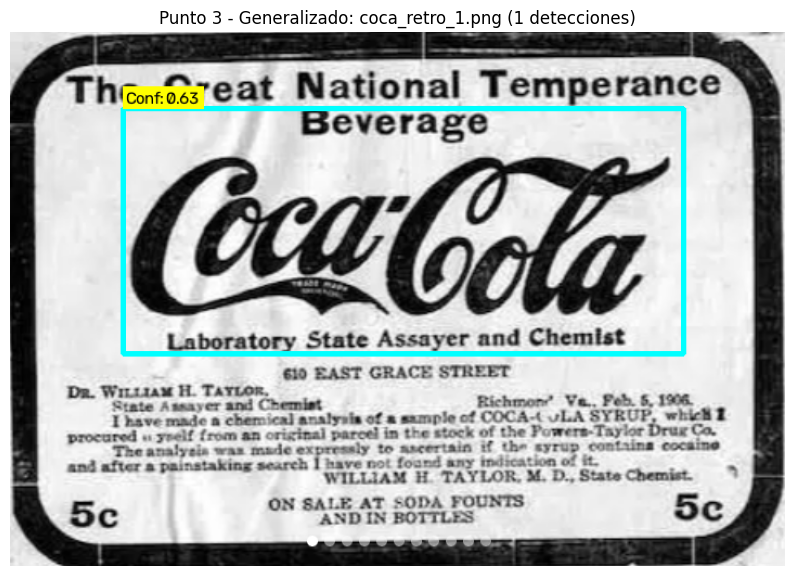

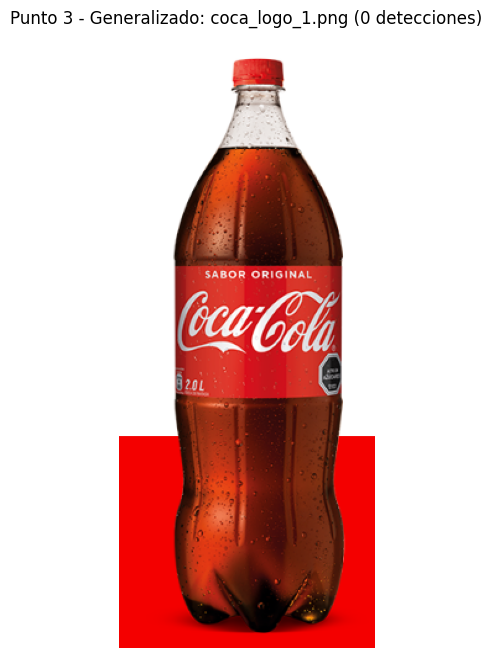

In [57]:

# Supresión de no maximos
def non_max_suppression_iou(boxes, overlapThresh=0.3):
    if len(boxes) == 0:
        return np.array([])

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    scores = boxes[:, 4]

    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    idxs = np.argsort(scores)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        intersection = w * h
        iou = intersection / (area[i] + area[idxs[:last]] - intersection)

        idxs = np.delete(idxs, np.concatenate(([last], np.where(iou > overlapThresh)[0])))

    return boxes[pick]

# Deteccion multiescala con filtro HSV y match template
def detect_multi_scale(image_bgr, template_gray, threshold=0.55, scales=np.linspace(0.3, 1.8, 20)):
    gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)
    tH, tW = template_gray.shape[:2]
    raw_boxes = []

    for scale in scales:
        # Redimensionar la imagen para buscar el template en diferentes tamaños
        # Ajustar la escala para que el template no sea más grande que la imagen redimensionada
        if gray.shape[1] * scale < tW or gray.shape[0] * scale < tH:
            continue

        resized = cv.resize(gray, (int(gray.shape[1] * scale), int(gray.shape[0] * scale)))

        # Calcular el factor de escala inverso para mapear las coordenadas detectadas de nuevo a la imagen original
        r = gray.shape[1] / float(resized.shape[1])

        res = cv.matchTemplate(resized, template_gray, cv.TM_CCOEFF_NORMED)
        loc = np.where(res >= threshold)

        for pt in zip(*loc[::-1]):
            x1 = int(pt[0] * r)
            y1 = int(pt[1] * r)
            x2 = int((pt[0] + tW) * r)
            y2 = int((pt[1] + tH) * r)
            score = float(res[pt[1], pt[0]])
            raw_boxes.append([x1, y1, x2, y2, score])

    return non_max_suppression_iou(raw_boxes, overlapThresh=0.37)

# Visualizacion
def dibujar_y_mostrar(img_bgr, boxes, titulo=""):
    img_draw = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    for box in boxes:
        x1, y1, x2, y2, score = int(box[0]), int(box[1]), int(box[2]), int(box[3]), box[4]

        # Bounding Box Cian/Celeste brillante
        cv.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 255), 3)

        # Etiqueta con fondo amarillo para legibilidad
        label = f"Conf: {score:.2f}"
        font = cv.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        thickness = 1

        (w, h), _ = cv.getTextSize(label, font, font_scale, thickness)

        # Posición de la caja de texto
        text_y1 = max(y1 - h - 6, 0)
        cv.rectangle(img_draw, (x1, text_y1), (x1 + w + 6, text_y1 + h + 6), (255, 255, 0), -1)
        cv.putText(img_draw, label, (x1 + 3, text_y1 + h + 2), font, font_scale, (0, 0, 0), thickness, cv.LINE_AA)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_draw)
    plt.title(f"{titulo} ({len(boxes)} detecciones)")
    plt.axis("off")
    plt.show()

# Ejecución
# Usar rutas relativas locales
template_path = Path("template") / "pattern.png"
images_dir = Path("images")

template = cv.imread(str(template_path), cv.IMREAD_GRAYSCALE)

if template is None:
    print(f"ERROR: No se pudo cargar el template desde: {template_path}")
else:
    imagenes_a_procesar = [
        "coca_multi.png",
        "coca_retro_2.png",
        "logo_1.png",
        "coca_logo_2.png",
        "COCA-COLA-LOGO.jpg",
        "coca_retro_1.png",
        "coca_logo_1.png"
    ]

    for img_name in imagenes_a_procesar:
        path_img = images_dir / img_name
        
        if not path_img.exists():
            print(f"ADVERTENCIA: {img_name} no encontrado en {images_dir}")
            continue
            
        img_bgr = cv.imread(str(path_img))

        if img_bgr is not None and template is not None:
            # Ajustando esto se pasa a no detectar o a falsos positivos -- Umbral ajustado a 0.37
            boxes = detect_multi_scale(img_bgr, template, threshold=0.37)
            dibujar_y_mostrar(img_bgr, boxes, titulo=f"Punto 3 - Generalizado: {img_name}")
        else:
            print(f"No se pudo cargar {img_name} o el template.")